# Dutch Markets: a mock of the vAMM + Challenge/Auction mechanism

This explores the mechanism described in `idea.md`: an oracle-less market that
floats freely on a vAMM (`x*y=k`), and self-corrects whenever it drifts too far
from a "true" external price via a Challenge (bond-gated pause) followed by a
Dutch auction (price discovery via a decaying auction that an arbitrageur fills).

All the trading flow here comes from **`CoinflipTrader`** agents — no strategy, no
information edge, just a coin flip for direction and a random size. That's on
purpose: the point is to isolate what the *mechanism itself* contributes (does the
market stay near true value, purely from the challenge/auction loop, with zero
smart money doing continuous arbitrage in the floating phase?) rather than measure
any trading skill.

The original idea left three things unspecified. This version makes a concrete
call on each and the notebook tests it:

1. **Where does the challenger's bounty come from**, given the idea explicitly
   rules out funding fees? -> a small taker fee on every trade funds a protocol
   reserve (section 5).
2. **What happens when the Dutch auction decays through its whole range with no
   fill** (the true price moved further/faster than the auction could search)?
   -> auto-retry with a widened range, same bond held throughout, capped retries
   before a rare circuit-breaker fallback (section 8).
3. **What happens when a violent re-rating jumps a trader's equity straight past
   zero into deep negative territory** in a single tick -- who eats that "bad
   debt"? -> the same fee reserve doubles as an insurance fund; if it's ever
   insufficient, the shortfall is tracked explicitly rather than hand-waved away
   (section 7).

Classes live in `vamm.py`, `agents.py`, `auction.py`, `market.py`, `simulation.py`
in this same folder.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dutch_markets import Simulation, Phase

# --- shared chart styling: fixed colors per entity, used consistently across every plot ---
COLOR_VAMM = "#2a78d6"     # vAMM price (blue)
COLOR_TRUE = "#e34948"     # true / real-world reference price (red)
COLOR_EVENT = "#1baf7a"    # challenge / fill markers (aqua)
COLOR_WARN = "#eda100"     # auction-phase shading / secondary series (yellow)
GRID = "#e1e0d9"
INK = "#0b0b0b"
MUTED = "#898781"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": GRID,
    "axes.grid": True,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})


## Run the simulation

Defaults were tuned (see the parameter sweep near the bottom) so the market spends
roughly two-thirds of its time floating and one-third frozen in an auction — enough
of both regimes to look at.


In [2]:
sim = Simulation(seed=7)
df = sim.run()
events = sim.events_df()

print(f"{len(df)} ticks -- {(df['phase']=='FLOATING').mean():.0%} floating / {(df['phase']=='AUCTION').mean():.0%} in auction")
print(f"{(events['type']=='challenge').sum()} challenges, "
      f"{(events['type']=='fill').sum()} filled, "
      f"{(events['type']=='retry').sum()} retried, "
      f"{(events['type']=='circuit_breaker_settle').sum()} hit the circuit breaker")
df.head()


3000 ticks -- 69% floating / 31% in auction
96 challenges, 95 filled, 0 retried, 0 hit the circuit breaker


,tick,true_price,vamm_price,phase,divergence,n_liquidated,total_equity,tvl,reserve,unfunded_bounty,unfunded_bad_debt
0,0,99.999692,99.438817,FLOATING,0.005609,0,300002.552487,299998.604822,1.395178,0.0,0.0
1,1,99.742636,100.584602,FLOATING,0.008441,0,300000.043681,299995.784132,4.215868,0.0,0.0
2,2,99.383441,100.566167,FLOATING,0.011901,0,299997.128855,299993.133351,6.866649,0.0,0.0
3,3,99.767373,99.926116,FLOATING,0.001591,0,299990.736213,299990.667952,9.332048,0.0,0.0
4,4,100.372985,98.012181,FLOATING,0.023520,0,300036.231286,299986.341398,13.658602,0.0,0.0


## 1. Does the vAMM actually track the true price?

The true price (red) is an independent random walk standing in for "the real
world." The vAMM price (blue) only moves when a coinflip trader trades against the
curve, or when an auction re-rates it. Shaded bands are ticks where the market is
frozen in an auction.


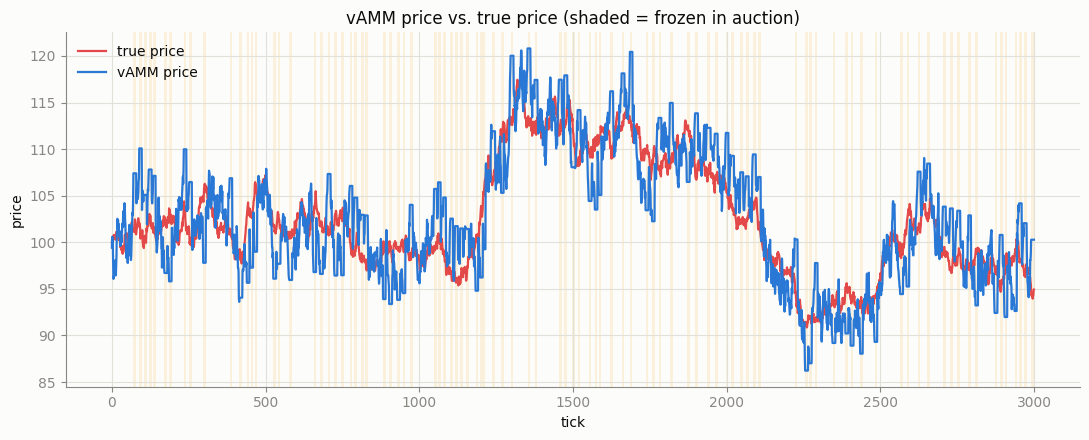

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5))

# shade auction (frozen) regions
in_auction = df["phase"].eq("AUCTION")
starts = df.index[in_auction & ~in_auction.shift(1, fill_value=False)]
ends = df.index[in_auction & ~in_auction.shift(-1, fill_value=False)]
for s, e in zip(starts, ends):
    ax.axvspan(s, e, color=COLOR_WARN, alpha=0.12, lw=0)

ax.plot(df["tick"], df["true_price"], color=COLOR_TRUE, lw=1.6, label="true price")
ax.plot(df["tick"], df["vamm_price"], color=COLOR_VAMM, lw=1.6, label="vAMM price")

ax.set_xlabel("tick")
ax.set_ylabel("price")
ax.set_title("vAMM price vs. true price (shaded = frozen in auction)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 2. Divergence over time

This is what the Challenger is watching: `|vAMM - true| / true`. The dashed line is
the challenge threshold — every time divergence crosses it, a challenge fires and
the line should snap back toward zero once the auction fills.


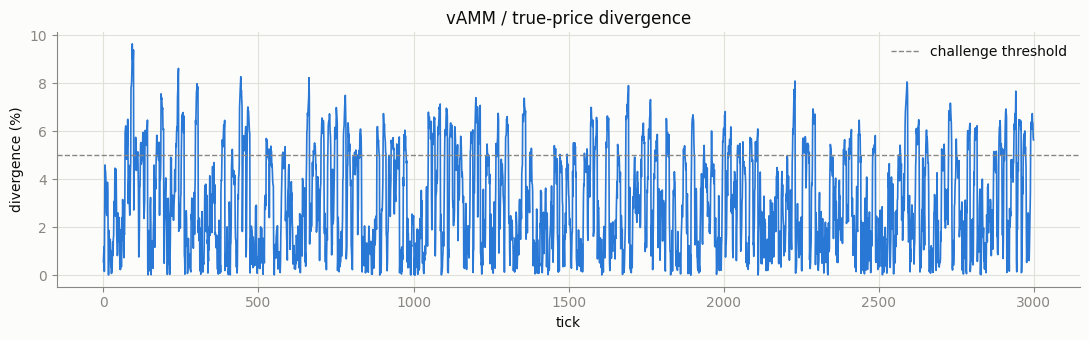

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(df["tick"], df["divergence"] * 100, color=COLOR_VAMM, lw=1.2)
ax.axhline(sim.market.challenge_threshold * 100, color=MUTED, lw=1, ls="--", label="challenge threshold")
ax.set_xlabel("tick")
ax.set_ylabel("divergence (%)")
ax.set_title("vAMM / true-price divergence")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 3. Zoom into a single challenge -> auction -> re-rate cycle

Picking the first cleanly-resolved auction episode (no retry needed): the vAMM is
frozen at the challenge tick, the auction price decays (dotted), and the moment it
crosses the arbitrageur's estimate of true value it's filled, and the vAMM
re-rates onto that fill price.


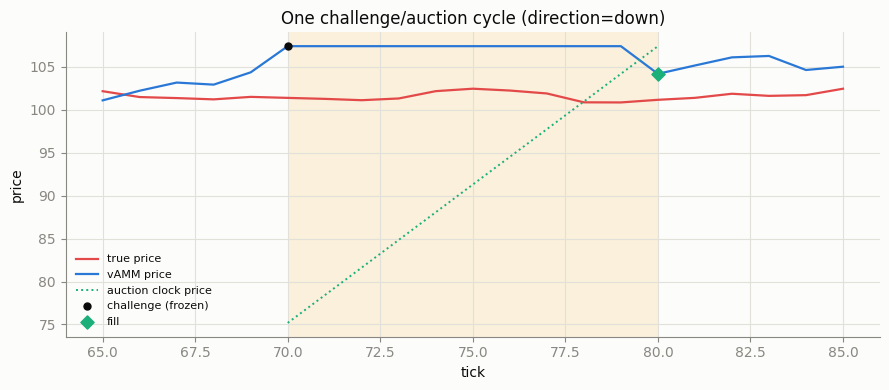

In [5]:
resolved = events[(events["type"] == "fill") & (events.get("retries", 0) == 0)]
challenges = events[events["type"] == "challenge"]

first_challenge = None
first_fill = None
for _, ch in challenges.iterrows():
    candidate = resolved[resolved["tick"] > ch["tick"]]
    if len(candidate):
        first_challenge, first_fill = ch, candidate.iloc[0]
        break

t0, t1 = int(first_challenge["tick"]), int(first_fill["tick"])
window = df[(df["tick"] >= t0 - 5) & (df["tick"] <= t1 + 5)]

direction = first_challenge["direction"]
frozen_price = first_challenge["vamm_price"]
from dutch_markets.auction import DutchAuction
auc = DutchAuction(frozen_price, direction, sim.market.auction_range_pct, sim.market.auction_duration)
auction_ticks = list(range(t0, t1 + 1))
auction_prices = []
for _ in auction_ticks:
    auction_prices.append(auc.price_now())
    auc.step()

fig, ax = plt.subplots(figsize=(9, 4))
ax.axvspan(t0, t1, color=COLOR_WARN, alpha=0.12, lw=0)
ax.plot(window["tick"], window["true_price"], color=COLOR_TRUE, lw=1.6, label="true price")
ax.plot(window["tick"], window["vamm_price"], color=COLOR_VAMM, lw=1.6, label="vAMM price")
ax.plot(auction_ticks, auction_prices, color=COLOR_EVENT, lw=1.4, ls=":", label="auction clock price")
ax.scatter([t0], [frozen_price], color=INK, zorder=5, s=25, label="challenge (frozen)")
ax.scatter([t1], [first_fill["fill_price"]], color=COLOR_EVENT, zorder=5, s=45, marker="D", label="fill")

ax.set_xlabel("tick")
ax.set_ylabel("price")
ax.set_title(f"One challenge/auction cycle (direction={direction})")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


## 4. Bond economics

The Challenger's bond scales with how far price had drifted (`base_bond_pct` up to
`max_bond_pct` of TVL). Deeper divergence at challenge time -> bigger bond required
to challenge -- the "skin in the game" the idea calls for.


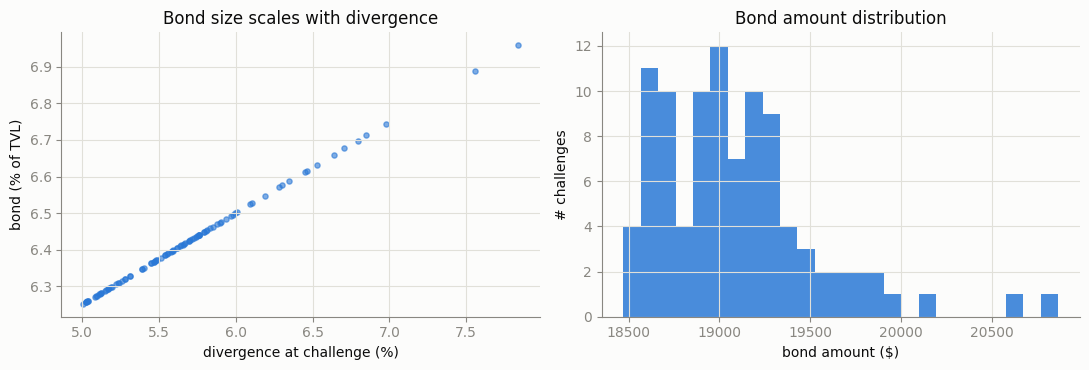

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].scatter(challenges["divergence"] * 100, challenges["bond_pct"] * 100,
                color=COLOR_VAMM, s=14, alpha=0.6)
axes[0].set_xlabel("divergence at challenge (%)")
axes[0].set_ylabel("bond (% of TVL)")
axes[0].set_title("Bond size scales with divergence")

axes[1].hist(challenges["bond_amount"], bins=25, color=COLOR_VAMM, alpha=0.85)
axes[1].set_xlabel("bond amount ($)")
axes[1].set_ylabel("# challenges")
axes[1].set_title("Bond amount distribution")

plt.tight_layout()
plt.show()


## 5. Open question 1 resolved: the fee-funded reserve pays the bounty

Every coinflip trade pays a small taker fee (`fee_bps`, straight out of collateral)
into `market.reserve`. On each fill, the bounty is sized as a cut of *that reserve*
-- not as a cut of the (much larger, TVL-scaled) bond. That distinction matters: an
earlier version of this sized the bounty off the bond and it demanded **~35x more
than the fees ever brought in** (176k unfunded against 5k of fee revenue) over this
same run. Sizing off the reserve instead makes the payout self-limiting by
construction -- `unfunded_bounty` should be exactly zero below.


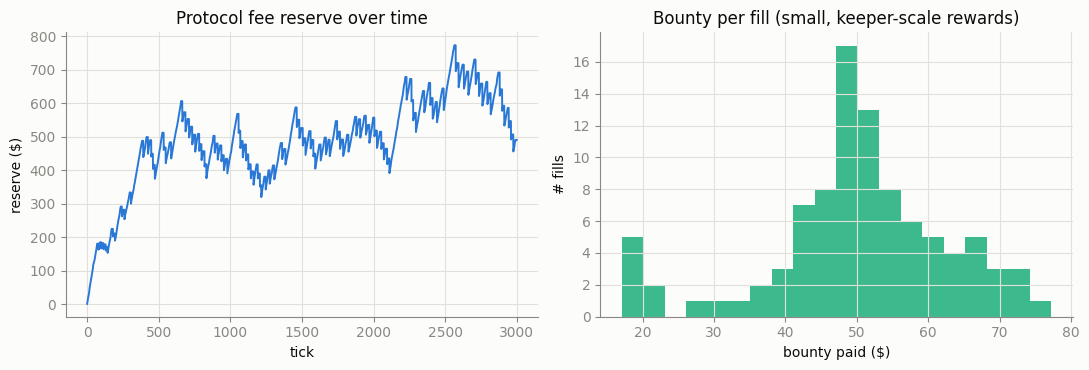

total fees collected: 5,234.12
total bounty paid out: 4,744.10
unfunded bounty (should be 0.0 by construction): 0.00
reserve remaining at end: 490.02


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].plot(df["tick"], df["reserve"], color=COLOR_VAMM, lw=1.4)
axes[0].set_xlabel("tick")
axes[0].set_ylabel("reserve ($)")
axes[0].set_title("Protocol fee reserve over time")

fills = events[events["type"] == "fill"]
axes[1].hist(fills["bounty_paid"], bins=20, color=COLOR_EVENT, alpha=0.85)
axes[1].set_xlabel("bounty paid ($)")
axes[1].set_ylabel("# fills")
axes[1].set_title("Bounty per fill (small, keeper-scale rewards)")

plt.tight_layout()
plt.show()

print(f"total fees collected: {sim.total_fees:,.2f}")
print(f"total bounty paid out: {fills['bounty_paid'].sum():,.2f}")
print(f"unfunded bounty (should be 0.0 by construction): {sim.market.unfunded_bounty:,.2f}")
print(f"reserve remaining at end: {sim.market.reserve:,.2f}")


## 6. Trader outcomes

These agents have zero edge -- pure coinflips. Any spread in final equity is noise
(AMM slippage + the new taker fee + the timing luck of who traded right before an
auction re-rating), not skill. Watch for anyone fully liquidated.


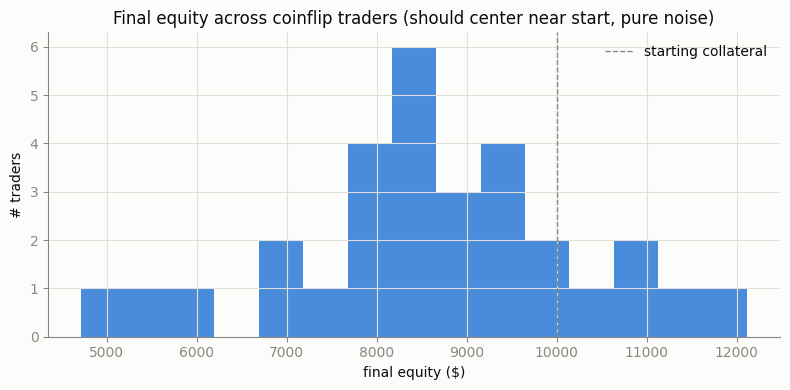

0 / 30 traders liquidated
mean final equity: 8,668  (started at 10,000)


In [8]:
final_price = df["vamm_price"].iloc[-1]
final_equity = [t.equity(final_price) for t in sim.traders]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(final_equity, bins=15, color=COLOR_VAMM, alpha=0.85)
ax.axvline(10_000, color=MUTED, lw=1, ls="--", label="starting collateral")
ax.set_xlabel("final equity ($)")
ax.set_ylabel("# traders")
ax.set_title("Final equity across coinflip traders (should center near start, pure noise)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

n_liq = sum(t.liquidated for t in sim.traders)
print(f"{n_liq} / {len(sim.traders)} traders liquidated")
print(f"mean final equity: {np.mean(final_equity):,.0f}  (started at 10,000)")


## 7. Open question 3 resolved: bad debt and the insurance-fund question

A re-rating moves price in one discrete jump, not continuously -- so a trader's
equity can blow straight through zero into deep negative territory before
`check_liquidation` ever runs. That shortfall ("bad debt") isn't covered by their
own collateral; the idea never says who eats it. Here it's routed into the same
fee reserve as the bounty, so it's directly comparable: is fee income actually
enough to insure against violent re-ratings, or does it get overwhelmed?

The tuned defaults above barely stress this (generous collateral, modest position
sizes -> little to no bad debt). To actually see the failure mode, thin out
collateral and push position sizes up, so re-ratings can jump traders past zero:


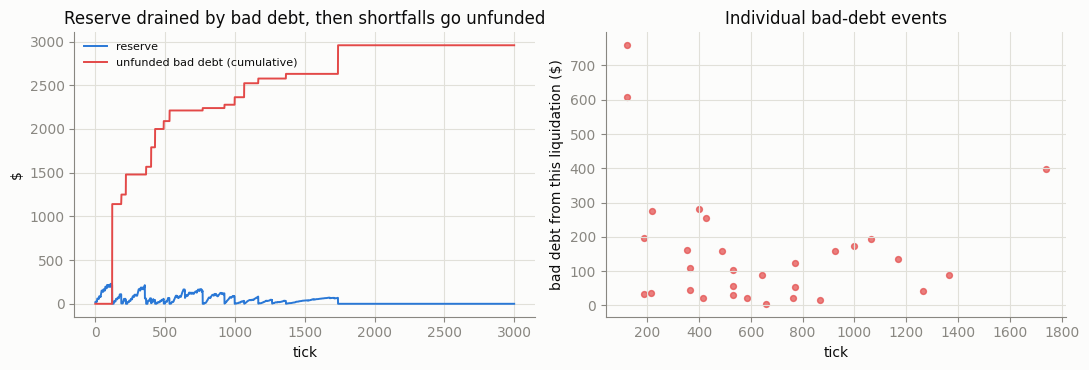

30 / 30 traders liquidated
total fees collected: 2,272.33
total bad debt realized: 4,655.20
unfunded bad debt (genuinely uncovered): 2,957.55


In [9]:
stress_debt = Simulation(
    ticks=3000, seed=3,
    trader_collateral=2_000.0,   # thin margin
    notional_mean=1_500.0,       # big positions relative to that margin
    trade_prob=0.5,
)
df_debt = stress_debt.run()
ev_debt = stress_debt.events_df()
bad_debt = stress_debt.bad_debt_df()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].plot(df_debt["tick"], df_debt["reserve"], color=COLOR_VAMM, lw=1.4, label="reserve")
axes[0].plot(df_debt["tick"], df_debt["unfunded_bad_debt"], color=COLOR_TRUE, lw=1.4, label="unfunded bad debt (cumulative)")
axes[0].set_xlabel("tick")
axes[0].set_ylabel("$")
axes[0].set_title("Reserve drained by bad debt, then shortfalls go unfunded")
axes[0].legend(frameon=False, fontsize=8)

if len(bad_debt):
    axes[1].scatter(bad_debt["tick"], bad_debt["shortfall"], color=COLOR_TRUE, s=18, alpha=0.7)
axes[1].set_xlabel("tick")
axes[1].set_ylabel("bad debt from this liquidation ($)")
axes[1].set_title("Individual bad-debt events")

plt.tight_layout()
plt.show()

print(f"{df_debt['n_liquidated'].iloc[-1]} / {len(stress_debt.traders)} traders liquidated")
print(f"total fees collected: {stress_debt.total_fees:,.2f}")
print(f"total bad debt realized: {stress_debt.total_bad_debt:,.2f}")
print(f"unfunded bad debt (genuinely uncovered): {stress_debt.market.unfunded_bad_debt:,.2f}")


Under thin-margin, large-position conditions the reserve gets fully drained and a
real chunk of bad debt goes uncovered -- a genuine protocol-insolvency risk that
the original idea doesn't address at all. This is the strongest argument in this
mock for either (a) tighter per-position margin requirements relative to vAMM
depth/volatility, or (b) a real insurance fund seeded independently of trading fees
(e.g. a protocol treasury allocation), not just fee income alone.


## 8. Parameter sensitivity: vAMM depth & challenge threshold

Deeper virtual liquidity (`initial_depth`) means each coinflip trade moves price
less, so the vAMM drifts from true value more slowly -- fewer challenges needed. A
tighter threshold catches divergence sooner but challenges (and freezes the market)
more often. This is the core tradeoff the design has to tune.


In [10]:
depths = [1_000, 3_000, 5_000, 8_000]
thresholds = [0.03, 0.05, 0.08]

rows = []
for depth in depths:
    for thresh in thresholds:
        s = Simulation(initial_depth=depth, challenge_threshold=thresh, ticks=2000, seed=3)
        d = s.run()
        e = s.events_df()
        rows.append({
            "depth": depth,
            "threshold": thresh,
            "floating_pct": (d["phase"] == "FLOATING").mean(),
            "n_challenges": (e["type"] == "challenge").sum() if len(e) else 0,
            "mean_divergence_pct": d["divergence"].mean() * 100,
        })
sweep = pd.DataFrame(rows)
sweep


,depth,threshold,floating_pct,n_challenges,mean_divergence_pct
0,1000,0.03,0.1665,178,5.246906
1,1000,0.05,0.2510,170,6.324946
2,1000,0.08,0.3790,162,7.988408
3,3000,0.03,0.2925,141,3.346133
4,3000,0.05,0.5795,90,3.722556
5,3000,0.08,0.7455,61,4.467294
6,5000,0.03,0.4865,100,2.465027
7,5000,0.05,0.7140,59,2.978596
8,5000,0.08,0.8725,30,3.789378
9,8000,0.03,0.6040,77,2.147940


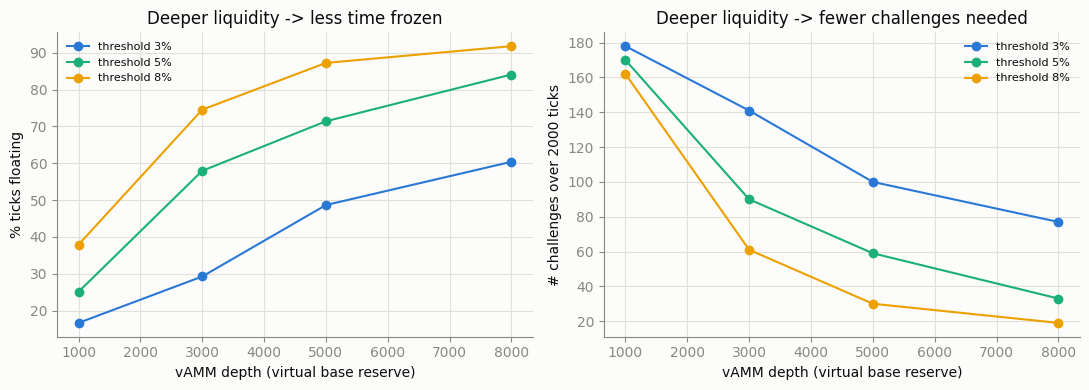

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
palette = [COLOR_VAMM, COLOR_EVENT, COLOR_WARN]  # one color per threshold, fixed order

for i, thresh in enumerate(thresholds):
    sub = sweep[sweep["threshold"] == thresh]
    axes[0].plot(sub["depth"], sub["floating_pct"] * 100, marker="o", color=palette[i],
                 label=f"threshold {thresh:.0%}")
    axes[1].plot(sub["depth"], sub["n_challenges"], marker="o", color=palette[i],
                 label=f"threshold {thresh:.0%}")

axes[0].set_xlabel("vAMM depth (virtual base reserve)")
axes[0].set_ylabel("% ticks floating")
axes[0].set_title("Deeper liquidity -> less time frozen")
axes[0].legend(frameon=False, fontsize=8)

axes[1].set_xlabel("vAMM depth (virtual base reserve)")
axes[1].set_ylabel("# challenges over 2000 ticks")
axes[1].set_title("Deeper liquidity -> fewer challenges needed")
axes[1].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()


## 9. Open question 2 resolved: auto-widening retries instead of silent no-fills

The auction only searches within `auction_range_pct` of the frozen price. The
original version just settled at whatever boundary it decayed to when nobody
filled -- accomplishing nothing, leaving the market still mispriced. Now, on
expiry, the market relaunches the auction with a widened range (same bond held
throughout) up to `max_auction_retries` times before a rare circuit-breaker
fallback. Forcing the stress case that used to produce persistent unresolved
mispricing (fast-moving reference + a narrow initial range):


178 challenges, 177 filled, 14 retried (widened range), 1 hit the circuit breaker


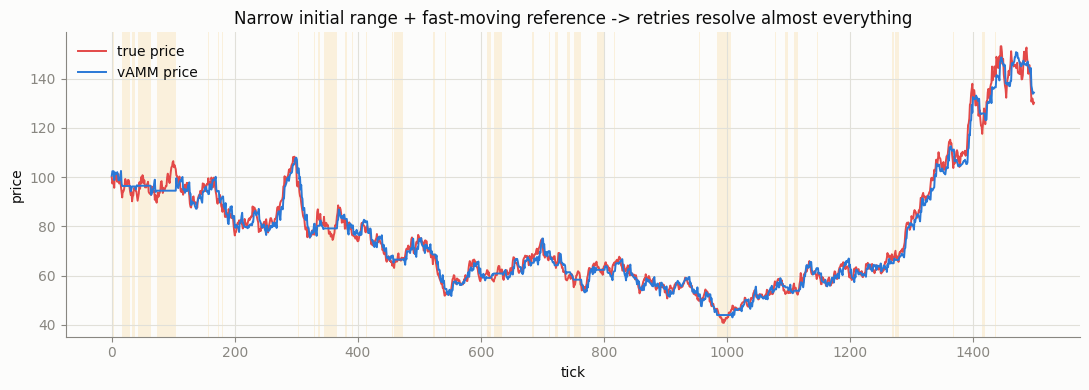

In [12]:
stress = Simulation(
    ticks=1500, seed=11,
    true_price_sigma=0.02,      # much faster-moving reference
    auction_range_pct=0.05,     # auction only searches +/-5% initially
    auction_duration=8,
)
df_stress = stress.run()
ev_stress = stress.events_df()

print(f"{(ev_stress['type']=='challenge').sum()} challenges, "
      f"{(ev_stress['type']=='fill').sum()} filled, "
      f"{(ev_stress['type']=='retry').sum()} retried (widened range), "
      f"{(ev_stress['type']=='circuit_breaker_settle').sum()} hit the circuit breaker")

fig, ax = plt.subplots(figsize=(11, 4))
in_auction = df_stress["phase"].eq("AUCTION")
starts = df_stress.index[in_auction & ~in_auction.shift(1, fill_value=False)]
ends = df_stress.index[in_auction & ~in_auction.shift(-1, fill_value=False)]
for s, e in zip(starts, ends):
    ax.axvspan(s, e, color=COLOR_WARN, alpha=0.12, lw=0)

ax.plot(df_stress["tick"], df_stress["true_price"], color=COLOR_TRUE, lw=1.4, label="true price")
ax.plot(df_stress["tick"], df_stress["vamm_price"], color=COLOR_VAMM, lw=1.4, label="vAMM price")
ax.set_xlabel("tick")
ax.set_ylabel("price")
ax.set_title("Narrow initial range + fast-moving reference -> retries resolve almost everything")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


Nearly everything that used to expire unresolved now gets caught by a retry with a
wider range; only a small handful ever reach the circuit breaker. Auctions run
longer in aggregate (more frozen time), but the market actually gets back near true
value almost every time, instead of reopening still wrong.


## 10. A proposed fix: the "Forced-Position Dutch Auction" -- does it hold up?

The worry motivating this proposal is legitimate: nowhere so far have we actually
*derived* the Arbitrageur's fill behavior from a real payoff. `Arbitrageur.wants_to_fill`
was hard-coded to "fill once the price crosses my estimate of true value" -- that's
an assumption about behavior, not a consequence of incentives. The proposal tries
to fix that gap by (1) forcing whoever fills into a real position at the fill price,
so their P&L is genuinely tied to how close they got to true value, and (2) paying
a real cash bounty (funded by slashing the LP vault) so filling is always worth
attempting. The claim: competition between arbitrageurs -- afraid of overpaying, but
also afraid of being beaten to the fill -- forces the price to converge *exactly* to
true value.

That convergence claim is testable, and it's worth testing before trusting it,
because it maps onto a specific, well-studied auction-theory setup: a **first-price,
common-value race**. In a Dutch auction where price decays monotonically and
multiple bidders each have their own noisy private estimate of the same true value,
the bidder who triggers *first* is not "whoever is right" -- it's mechanically
whoever has the most extreme estimate in the direction that crosses the decaying
price soonest. That's the textbook **winner's curse**, and it gets *worse*, not
better, as more competitors join. Let's check whether that's actually what happens
here, using the same `Arbitrageur` and `DutchAuction` classes already in this repo
(`forced_position.py`).


In [13]:
from dutch_markets.forced_position import run_experiment

rows = run_experiment(
    true_price=40.0, frozen_price=30.0, direction="up",
    auction_range_pct=0.5, auction_duration=40,
    n_bots_list=(1, 2, 5, 10, 25, 50, 100), noise_std=0.03,
    n_trials=3000, seed=1,
)
curse = pd.DataFrame(rows)
curse


,n_bots,n_filled,n_trials,mean_fill_price,bias_pct,std_fill_price
0,1,3000,3000,39.76965,-0.575875,1.201778
1,2,3000,3000,40.45005,1.125125,1.004486
2,5,3000,3000,41.15085,2.877125,0.807637
3,10,3000,3000,41.61660,4.041500,0.737000
4,25,3000,3000,42.12735,5.318375,0.623506
5,50,3000,3000,42.46110,6.152750,0.568944
6,100,3000,3000,42.77790,6.944750,0.535763


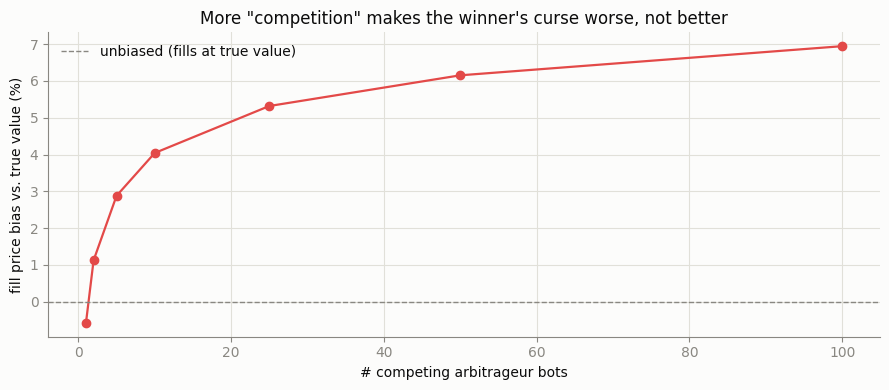

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(curse["n_bots"], curse["bias_pct"], marker="o", color=COLOR_TRUE, lw=1.6)
ax.axhline(0, color=MUTED, lw=1, ls="--", label="unbiased (fills at true value)")
ax.set_xlabel("# competing arbitrageur bots")
ax.set_ylabel("fill price bias vs. true value (%)")
ax.set_title("More \"competition\" makes the winner's curse worse, not better")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


With a single bot, the fill is unbiased (small noise either way). With 100
competing bots racing to fill first, the fill price is biased **~7% above true
value** on average -- systematically, every time, with no lying required. The
"winner" is just whoever happened to have the most optimistic private estimate;
more bots racing means a larger pool to draw an extreme estimate from, so the
expected overpayment grows (this is the max of n noisy draws, which grows with
`sqrt(log(n))` -- slow, but relentless and in the wrong direction).

This directly contradicts Scenario C's "equilibrium converges to true value"
claim: it only holds with a *single* rational actor reasoning about being
sniped, not with the many competing bots the proposal explicitly wants to attract
for a liquid, decentralized fill market. The fix that real common-value auctions
use is **bid shading**: rational bidders discount their trigger below their raw
belief to compensate for the fact that winning is itself bad news about their
estimate. Does that actually fix it here?


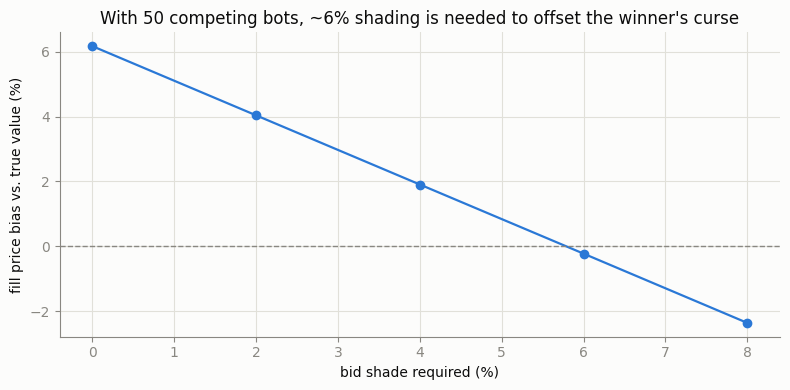

,shade_pct,bias_pct
0,0.0,6.172625
1,2.0,4.039625
2,4.0,1.906625
3,6.0,-0.224875
4,8.0,-2.360500


In [15]:
shade_rows = []
for shade in [0.0, 0.02, 0.04, 0.06, 0.08]:
    r = run_experiment(n_bots_list=(50,), noise_std=0.03, n_trials=3000, seed=1, shade=shade)[0]
    shade_rows.append({"shade_pct": shade * 100, "bias_pct": r["bias_pct"]})
shade_df = pd.DataFrame(shade_rows)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(shade_df["shade_pct"], shade_df["bias_pct"], marker="o", color=COLOR_VAMM, lw=1.6)
ax.axhline(0, color=MUTED, lw=1, ls="--")
ax.set_xlabel("bid shade required (%)")
ax.set_ylabel("fill price bias vs. true value (%)")
ax.set_title("With 50 competing bots, ~6% shading is needed to offset the winner's curse")
plt.tight_layout()
plt.show()
shade_df


Shading does fix the bias -- but it requires each bot to know (or estimate) roughly
how many competitors it's racing against and how noisy their beliefs are, then
shade accordingly. That's a much less "free-market obvious" strategy than "click
Fill the instant it's profitable," which is exactly what the original proposal's
Scenario A/B/C reasoning assumed bots would naturally do. In practice this means
either sophisticated bots converge on the right shade over time (plausible, but not
guaranteed, and different bots may shade differently, widening the fill-price
distribution) or the naive version ships and quietly overpays by single-digit
percent on every correction, which is a real, measurable cost -- not the "perfect
market" framing the proposal uses.

**The other three issues with the proposal, reasoned through rather than
simulated:**

- **Where the cash bounty comes from.** Slashing the LP vault assumes real LPs
  back the vAMM -- that's not in `idea.md`, which only describes trader collateral
  against a purely virtual curve. If you do add LPs, they will (rationally) price
  in the risk of being slashed on every challenge as a spread or a yield demand --
  which is a cost of carry by another name, reopening the "zero funding fee" claim
  this whole design is trying to make.
- **Cross-venue manipulation.** "Financial suicide" for lying (Scenario A) only
  holds for an arbitrageur with no hedge elsewhere. A well-capitalized actor who
  already holds the opposite position on a real venue can profit overall even
  while "losing" on their forced position here -- they're not betting on this
  platform's price, they're using this platform's auction to move a *local* mark
  that benefits their *external* book. This is the same category of attack behind
  several real oracle/AMM exploits; forcing a position here doesn't defend against
  it, since the attacker's real P&L was never local to begin with.
- **A whale-only barrier, recreated.** The proposal opens by rejecting the
  vote-based dispute model *because* whales can dominate it -- but "mathematically
  forced to open a massive position" reintroduces the same asymmetry in a new
  shape: only an actor with enough capital and risk tolerance to safely hold a
  large, possibly-adverse-selected position can safely play Arbitrageur at all.
  Smaller participants are structurally priced out of exactly the role meant to
  keep the mechanism decentralized.

**Net recommendation:** the instinct behind the proposal is right -- there should
be a real, derivable payoff behind "why does anyone fill accurately," not an
assumption. But "force a large position + fund it by slashing LPs" isn't the way
to get there; it reintroduces LP funding costs, a whale barrier, and (per the
simulation above) a structural winner's-curse bias that gets worse with more
participants, which is the opposite of what you want from "more free-market
competition." The fee-funded, reserve-sized bounty already built in section 5 is
closer to the right shape (small, self-funding, doesn't require anyone to hold a
large forced position) -- it just needs the missing piece this section surfaced:
tie bounty eligibility (or size) to fill *accuracy* against some cheap sanity check
(e.g. a short TWAP of recent floating-phase trades), so the reward is actually
for being close to true value, not just for being first to click.


## Takeaways from this mock

- With plenty of vAMM depth relative to trade size, pure noise trading alone drifts
  the price slowly enough that the challenge/auction loop can keep it tethered to
  "true" value most of the time -- even with zero smart continuous arbitrage.
- The bond-scales-with-divergence design does what it says: bigger drift, bigger
  bond, which is the right shape to deter spam challenges on small/noisy
  divergence while still rewarding someone for catching a real dislocation.
- **Bounty source (resolved):** a small taker fee funds a reserve; sizing the
  bounty as a cut of *that reserve* rather than of the TVL-scaled bond keeps it
  self-funding by construction (section 5).
- **No-fill (resolved):** auto-widening retries turn "the market reopens still
  mispriced" into a rare circuit-breaker edge case instead of a routine outcome
  (section 9).
- **Bad debt (resolved, but not eliminated):** the same reserve can absorb the
  shortfall from a violent re-rating, but under thin margin / large positions it
  gets overwhelmed and real bad debt goes uncovered (section 7) -- this is the
  one open question where the honest answer is "the mechanism needs an explicit
  margin policy, fee income alone isn't guaranteed to be enough."
- **Forced-Position Dutch Auction (evaluated, not adopted):** a plausible-sounding
  fix for "is the fill actually tied to real value" turns out to have a structural
  winner's-curse bias that *worsens* with more competing arbitrageurs, plus a
  reintroduced whale barrier and LP-funding cost (section 10). The underlying
  worry was valid; this particular fix isn't the resolution.
- None of this required an oracle at any point -- the only external input was the
  arbitrageur's private belief about "true" value, used only to decide *when* to
  click fill, never fed into the contract directly.
